# Area-weighted Curvature distribution
The idea is that we create a histogram of the mean curvature in the membrane. And then weigh each gridpoint of curvature by the surface area in that gridpoint calculated from a parametrized surface.  

In [ ]:
import sys
sys.path.append("../")
from include import *
from analyzer_functions import *

In [ ]:
# Loading system information
upper_gro = "pseudo_universe_Lower_fitacc.pdb"
upper_xtc = "fourier_curvature_fitting_Upper.xtc"
lower_gro = "pseudo_universe_Upper_fitacc.pdb"
lower_xtc = "fourier_curvature_fitting_Lower.xtc"

upper_leaflet = load_mda_universe(calm_dir, upper_gro, upper_xtc)
lower_leaflet = load_mda_universe(calm_dir, lower_gro, lower_xtc)
                                                            
max_frame = get_max_frame(calm_dir) # Check the number of frames in the CALM output, should be the same as the number of frames in the original trajectory, but just to be sure
n_gridpoints = len(upper_leaflet.atoms)

# Allocating arrays
grid_curvatures = {
        "Upper": np.zeros(n_gridpoints*max_frame),
        "Lower": np.zeros(n_gridpoints*max_frame)
}
grid_weights = {
    "Upper": np.zeros(n_gridpoints*max_frame),
    "Lower": np.zeros(n_gridpoints*max_frame)
}

systems = {
    "Upper": upper_leaflet,
    "Lower": lower_leaflet
}

# Main loop
print("Currently assuming that the grid_area and curv_map have the same indexing!!!")
for frame_idx, ts in tqdm(enumerate(upper_leaflet.trajectory)):
    # Load curvature maps
    curv_map = {
        "Upper": load_npy(calm_dir, f"curvature_frame_{frame_idx+1}_Upper.npy", verbose=False),
        "Lower": -load_npy(calm_dir, f"curvature_frame_{frame_idx+1}_Lower.npy", verbose=False),
    }
    # Load the curvature map
    for key in systems:  # Flatten the curvature arrays
        curv_map[key] = curv_map[key].flatten()
        grid_curvatures[key][frame_idx*n_gridpoints:(frame_idx+1)*n_gridpoints] = curv_map[key]

    # Calculate the grid area
    for key in systems:
        height = systems[key].atoms.positions[:, -1] # We only need the z position as this is the height of the membrane
        height = np.reshape(height, (100, 100)) # Loading the height as a 100x100 grid
        grid_area, hx, hy = calc_surface_area(boxsize, height)
        grid_area = grid_area.flatten() # Flatten the grid area to match the curvature map
        grid_weights[key][frame_idx*n_gridpoints:(frame_idx+1)*n_gridpoints] = grid_area
    


Currently assuming that the grid_area and curv_map have the same indexing!!!


251it [00:08, 29.90it/s] 


Text(0, 0.5, 'Density of grid points - $P(c)$')

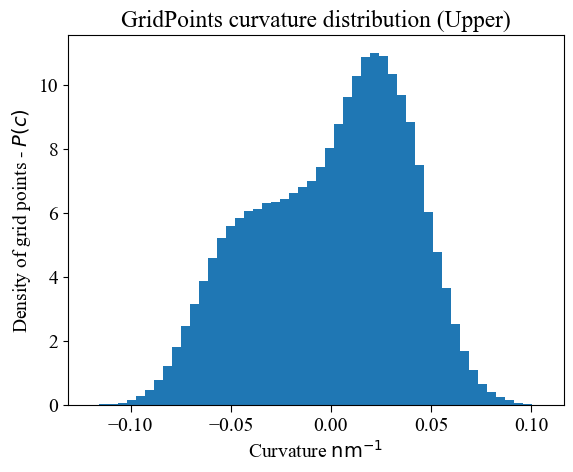

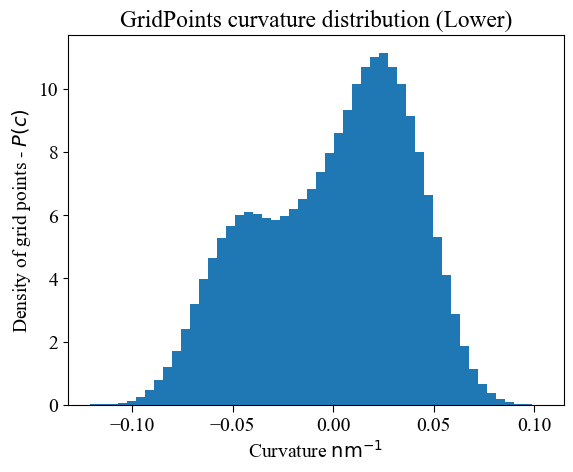

In [ ]:
# Plotting params
n_bins = 50

# Grid points histogram (Upper)
fig, ax = plt.subplots()
ax.hist(grid_curvatures["Upper"], bins=n_bins, density=True, weights=grid_weights["Upper"])
ax.set_title("GridPoints curvature distribution (Upper)")
ax.set_xlabel(r"Curvature $\text{nm}^{-1}$", fontsize = 14)
ax.set_ylabel("Density of grid points - $P(c)$")


# Grid points histogram (Lower)
fig, ax = plt.subplots()
ax.hist(grid_curvatures["Lower"], bins=n_bins, density=True, weights=grid_weights["Lower"])
ax.set_title("GridPoints curvature distribution (Lower)")
ax.set_xlabel(r"Curvature $\text{nm}^{-1}$", fontsize = 14)
ax.set_ylabel("Density of grid points - $P(c)$")

Text(0, 0.5, 'Density of grid points - $P(c)$')

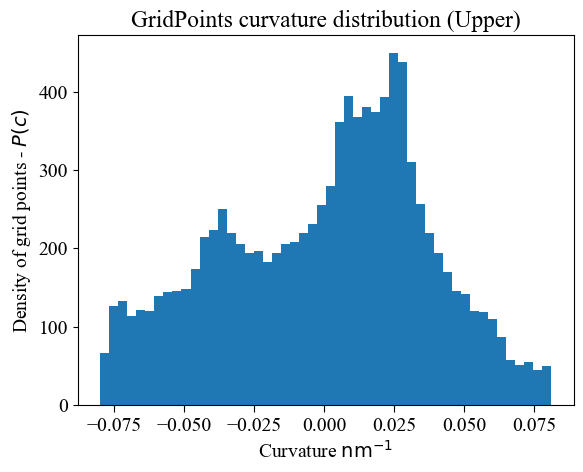

In [ ]:
# Plotting params
n_bins = 50

# Grid points histogram (Upper)
fig, ax = plt.subplots()
ax.hist(grid_curvatures["Upper"][0:10000], bins=n_bins)
ax.set_title("GridPoints curvature distribution (Upper)")
ax.set_xlabel(r"Curvature $\text{nm}^{-1}$", fontsize = 14)
ax.set_ylabel("Density of grid points - $P(c)$")
